# exp21 jon_exp21_modulation — evaluation

Loads `results/jon_exp21_modulation/<run>__<tag>__{in1k,recon}.pt`. Policy = `coarse_to_fine`, 21 timesteps (3 quadtree levels: 1+4+16), `canvas_grid=32`. Teacher + IN1k probe auto-selected per run (ViT-B / ViT-L).

Two sections:
- **Base (23 runs)** — one combined plot per metric; baseline = `exp21-cond4-reg-repro`.
- **Scale sweep** — the 3 scale-trained / control models (`per_glimpse`, `per_rollout`, and the scale-1-only `repro` **control**) at each eval scale: one panel per scale `{1.0, coarse-to-fine, 0.6, 0.8}`, overlaying the 3 models. `repro` is drawn as a black dashed control line.

`<tag>`: `policy` (= override None, policy's own coarse-to-fine zoom), `s1p0` (=1.0), `s0p6`, `s0p8`, `s1p41`.

In [2]:
from pathlib import Path
import re, shlex
import torch
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("/user/henrich1/u25995/jonathan/repos/CanViT-eval/results/jon_exp21_modulation")
SCRIPTS_DIR = Path("/user/henrich1/u25995/jonathan/repos/CanViT-pretrain/slurm_nhr/runs/jon_exp21_modulation")
BASELINE    = "exp21-cond4-reg-repro"

# The 3 scale-trained / control models, evaluated at several eval scales.
SCALE_MODELS = [
    "exp21-cond4-reg-scale-uniform-glimpse",   # per-glimpse random scale
    "exp21-cond4-reg-scale-uniform-rollout",   # per-rollout random scale
    "exp21-cond4-reg-repro",                   # scale-1-only CONTROL
]
SPECIAL_TAGS = ["policy", "s0p6", "s0p8"]                 # tags that DEFINE the special set
SPECIAL = {(m, t) for m in SCALE_MODELS for t in SPECIAL_TAGS}
SWEEP_TAGS = ["s1p0", "policy", "s0p6", "s0p8"]           # panels shown in the scale-sweep (incl. 1.0 ref)

MODEL_LABEL = {
    "exp21-cond4-reg-scale-uniform-glimpse": "per_glimpse",
    "exp21-cond4-reg-scale-uniform-rollout": "per_rollout",
    "exp21-cond4-reg-repro": "repro (scale-1 control)",
}
TAG_LABEL = {"s1p0": "scale=1.0 (ref)", "policy": "coarse-to-fine zoom",
             "s0p6": "scale=0.6", "s0p8": "scale=0.8", "s1p41": "scale=1.41"}

## Load results

Keyed by `(run, tag)`. Base set = every `(run, tag)` that is **not** in the special scale-sweep (so each run appears once, at its base scale). Missing files are skipped, so the notebook is runnable while the array is still filling in.

In [3]:
def _parse(name, suffix):
    run, tag = name[:-len(suffix)].rsplit("__", 1)
    return run, tag

in1k = {}   # (run, tag) -> [top1 per t]
for p in sorted(RESULTS_DIR.glob("*__in1k.pt")):
    run, tag = _parse(p.name, "__in1k.pt")
    r = torch.load(p, map_location="cpu", weights_only=False)
    preds, labels = r["top_k_preds"].long(), r["labels"].long()
    in1k[(run, tag)] = (preds[:, :, 0] == labels[:, None]).float().mean(0).tolist()

recon = {}  # (run, tag) -> {scene_cos_norm:[...], cls_cos_norm:[...], ...}
for p in sorted(RESULTS_DIR.glob("*__recon.pt")):
    run, tag = _parse(p.name, "__recon.pt")
    per = torch.load(p, map_location="cpu", weights_only=False)["per_timestep"]
    recon[(run, tag)] = {k: [d[k] for d in per]
                         for k in ("scene_cos_norm", "cls_cos_norm", "scene_cos_raw", "cls_cos_raw")}

BASE_in1k  = {k: v for k, v in in1k.items()  if k not in SPECIAL}
BASE_recon = {k: v for k, v in recon.items() if k not in SPECIAL}
# one entry per run (base tag); for the 3 scale-models this is their s1p0
base_in1k_by_run  = {run: v for (run, tag), v in BASE_in1k.items()}
base_recon_by_run = {run: v for (run, tag), v in BASE_recon.items()}

print(f"in1k:  {len(in1k):2d} configs  ({len(BASE_in1k)} base, {len(in1k)-len(BASE_in1k)} special)")
print(f"recon: {len(recon):2d} configs  ({len(BASE_recon)} base, {len(recon)-len(BASE_recon)} special)")
print(f"baseline present (in1k/recon): {BASELINE in base_in1k_by_run} / {BASELINE in base_recon_by_run}")

in1k:  32 configs  (23 base, 9 special)
recon: 32 configs  (23 base, 9 special)
baseline present (in1k/recon): True / True


## Base — param diff vs baseline (`cond4-reg-repro`)

Tokenize each run's `EXTRA_ARGS` and diff vs the baseline, giving a short string of only the params that distinguish each run (patcher, conditioning, scale-mode, …).

In [4]:
def parse_extra_args(path):
    if not path.exists():
        return {}
    m = re.search(r'^EXTRA_ARGS="([^"]*)"', path.read_text(), re.M)
    if not m:
        return {}
    toks, args, i = shlex.split(m.group(1)), {}, 0
    while i < len(toks):
        t = toks[i]
        if t.startswith("--"):
            if i + 1 < len(toks) and not toks[i + 1].startswith("--"):
                args[t] = toks[i + 1]; i += 2
            else:
                args[t] = True; i += 1
        else:
            i += 1
    return args

base_runs = sorted(set(base_in1k_by_run) | set(base_recon_by_run))
run_args = {run: parse_extra_args(SCRIPTS_DIR / f"{run}.sh") for run in base_runs}
baseline_args = run_args.get(BASELINE, {})

def _short(f):
    for p in ("--model.square-patcher.", "--model.foveated-patcher.", "--foveated-scale.", "--model."):
        if f.startswith(p):
            return f[len(p):]
    return f.removeprefix("--")

def diff_vs_baseline(a):
    d = []
    for k, v in a.items():
        if k not in baseline_args:
            d.append(f"+{_short(k)}" if v is True else f"+{_short(k)}={v}")
        elif baseline_args[k] != v:
            d.append(f"{_short(k)}: {baseline_args[k]}→{v}")
    for k in baseline_args:
        if k not in a:
            d.append(f"-{_short(k)}")
    return d

run_diffs = {run: diff_vs_baseline(args) for run, args in run_args.items()}

### IN1k top-1 — summary table

Baseline pinned on top; others sorted by final-glimpse top-1. `delta_final` = final top-1 − baseline.

In [5]:
rows = []
for run, top1 in base_in1k_by_run.items():
    diffs = run_diffs.get(run, [])
    rows.append({"run": run, "diff_vs_baseline": "  •  ".join(diffs) if diffs else "(BASELINE)",
                 "final": top1[-1], "max": max(top1)})
df = pd.DataFrame(rows)
if not df.empty:
    is_base = df["run"].eq(BASELINE)
    df = pd.concat([df[is_base], df[~is_base].sort_values("final", ascending=False)], ignore_index=True)
    bf = df.loc[df["run"] == BASELINE, "final"]
    df["delta_final"] = df["final"] - (bf.iloc[0] if len(bf) else float("nan"))
    df = df[["run", "diff_vs_baseline", "final", "max", "delta_final"]]
display(df.style.format({"final": "{:.4f}", "max": "{:.4f}", "delta_final": "{:+.4f}"})
        .background_gradient(subset=["delta_final"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)) if not df.empty else print("no in1k base results yet")

,run,diff_vs_baseline,final,max,delta_final
0,exp21-cond4-reg-repro,(BASELINE),0.6370,0.6370,+0.0000
1,exp21-uniform16-repro,patcher-name: square→uniform • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible,0.7311,0.7315,+0.0941
2,exp21-uniform8,patcher-name: square→uniform • +backbone-name=vitb8 • +glimpse-grid-size=8 • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.7241,0.7241,+0.0871
3,exp21-uniform16-L,patcher-name: square→uniform • +backbone-name=vitb16 • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible,0.6976,0.6976,+0.0606
4,exp21-cond4-reg-modulate-trunk-fourier,+backbone-name=vitb16_modulate • +vit-modulation.enabled,0.6771,0.6771,+0.0401
5,exp21-uniform-p6-grid6,patcher-name: square→uniform • +backbone-name=vitb6 • +glimpse-grid-size=6 • +n-backbone-registers=33 • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible,0.6706,0.6706,+0.0336
6,exp21-cond4-fovi-fov140-res81,patcher-name: square→foveated • +fov=140 • +resolution=81 • +cart-patch-size=10 • +arch-flag=doubleres • +no-force-patches-less-than-matched • +conditioning.mode=film • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4 • +n-backbone-registers=0 • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.6681,0.6681,+0.0311
7,exp21-cond4-reg-modulate-trunk-sinusoidal,+backbone-name=vitb16_modulate • +vit-modulation.enabled • +vit-modulation.encoding=sinusoidal,0.6658,0.6658,+0.0288
8,exp21-strided-gf2-keepcorners,method: fovi_regularized→strided • +grid-size-fovea=2 • +patch-size=8 • +edge-length-multipliers=2 • +n-backbone-registers=31 • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.6589,0.6591,+0.0219
9,exp21-cond4-reg-modulate-trunk-crossattn-fourier,+backbone-name=vitb16_modulate • +vit-modulation.enabled • +vit-modulation.modulate-cross-attn,0.6588,0.6588,+0.0218


### IN1k top-1 vs glimpse — line plot (all 23 base runs)

Baseline thick & black; others coloured (tab20+tab20b).

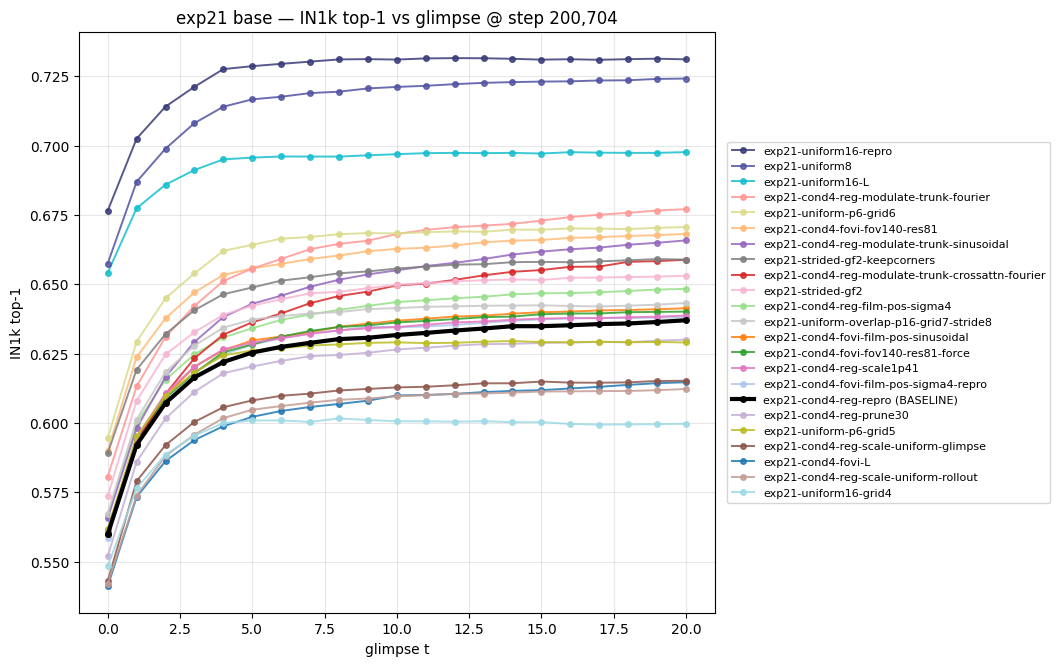

In [6]:
_palette = [plt.get_cmap("tab20")(i) for i in range(20)] + [plt.get_cmap("tab20b")(i) for i in range(20)]

def ranked_lineplot(by_run, ylabel, title):
    """Line plot whose legend is ordered top->bottom by each run's value at the
    LAST glimpse (descending), so the legend order matches the vertical order of
    the lines at the right edge. Colors are assigned by run name (stable across
    plots); the baseline keeps its black/thick highlight but is sorted in by its
    own final value like every other run."""
    if not by_run:
        print("no results yet"); return
    others = sorted(r for r in by_run if r != BASELINE)
    cmap = {r: _palette[i % len(_palette)] for i, r in enumerate(others)}
    fig, ax = plt.subplots(figsize=(12, 7))
    handles = {}  # run -> (line, final_value)
    for run in others + ([BASELINE] if BASELINE in by_run else []):
        y = by_run[run]; is_b = run == BASELINE
        (line,) = ax.plot(range(len(y)), y, marker="o", ms=4, lw=3 if is_b else 1.4,
                          alpha=1.0 if is_b else 0.85, color="black" if is_b else cmap[run],
                          label=f"{run}{' (BASELINE)' if is_b else ''}")
        handles[run] = (line, float(y[-1]))
    ax.set_xlabel("glimpse t"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.3)
    order = sorted(handles, key=lambda r: handles[r][1], reverse=True)  # best (highest final) on top
    ax.legend([handles[r][0] for r in order], [handles[r][0].get_label() for r in order],
              loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, borderaxespad=0)
    fig.subplots_adjust(left=0.07, right=0.60, top=0.93, bottom=0.10)
    plt.show()

ranked_lineplot(base_in1k_by_run, "IN1k top-1", "exp21 base — IN1k top-1 vs glimpse @ step 200,704")

### IN1k top-1 — Δ vs baseline at final glimpse

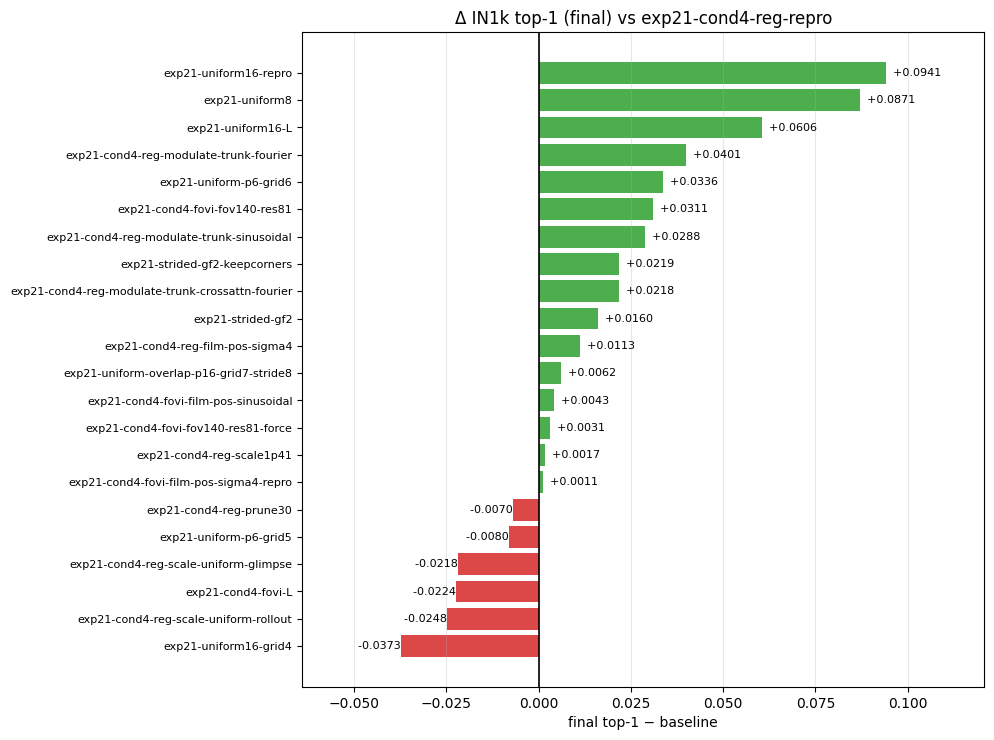

In [7]:
def delta_bars(by_run, idx, xlabel, title):
    if BASELINE not in by_run:
        print("baseline missing"); return
    bv = by_run[BASELINE][idx]
    ds = sorted([(r, by_run[r][idx] - bv) for r in by_run if r != BASELINE], key=lambda x: x[1])
    if not ds:
        print("no results yet"); return
    names, vals = [r for r, _ in ds], [d for _, d in ds]
    y = list(range(len(names)))
    fig, ax = plt.subplots(figsize=(11, max(4, 0.35 * len(ds))))
    ax.barh(y, vals, color=["#2ca02c" if d >= 0 else "#d62728" for d in vals], alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels(names, fontsize=8); ax.axvline(0, color="black", lw=1.2)
    ax.set_xlabel(xlabel); ax.set_title(title); ax.grid(True, alpha=0.3, axis="x")
    xmin, xmax = ax.get_xlim(); pad = max(abs(xmin), abs(xmax)) * 0.20
    ax.set_xlim(xmin - pad, xmax + pad)
    for i, d in zip(y, vals):
        ax.text(d, i, f"  {d:+.4f}", va="center", fontsize=8, ha="left" if d >= 0 else "right")
    fig.subplots_adjust(left=0.34, right=0.96, top=0.93, bottom=0.08)
    plt.show()

delta_bars(base_in1k_by_run, -1, f"final top-1 − baseline", f"Δ IN1k top-1 (final) vs {BASELINE}")

## Base — teacher reconstruction (cosine vs DINOv3)

`scene_cos_norm` (canvas patches vs teacher patches, standardized) and `cls_cos_norm` (recurrent CLS vs teacher CLS, standardized).

In [8]:
rows = []
for run, rr in base_recon_by_run.items():
    diffs = run_diffs.get(run, [])
    rows.append({"run": run, "diff_vs_baseline": "  •  ".join(diffs) if diffs else "(BASELINE)",
                 "scene_final": rr["scene_cos_norm"][-1], "cls_final": rr["cls_cos_norm"][-1]})
dfr = pd.DataFrame(rows)
if not dfr.empty:
    is_base = dfr["run"].eq(BASELINE)
    dfr = pd.concat([dfr[is_base], dfr[~is_base].sort_values("scene_final", ascending=False)], ignore_index=True)
    bs = dfr.loc[dfr["run"] == BASELINE, "scene_final"]; bc = dfr.loc[dfr["run"] == BASELINE, "cls_final"]
    dfr["Δscene"] = dfr["scene_final"] - (bs.iloc[0] if len(bs) else float("nan"))
    dfr["Δcls"]   = dfr["cls_final"]   - (bc.iloc[0] if len(bc) else float("nan"))
    dfr = dfr[["run", "diff_vs_baseline", "scene_final", "Δscene", "cls_final", "Δcls"]]
display(dfr.style.format({c: ("{:+.4f}" if c.startswith("Δ") else "{:.4f}")
                          for c in ["scene_final", "cls_final", "Δscene", "Δcls"]})
        .background_gradient(subset=["Δscene", "Δcls"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)) if not dfr.empty else print("no recon base results yet")

,run,diff_vs_baseline,scene_final,Δscene,cls_final,Δcls
0,exp21-cond4-reg-repro,(BASELINE),0.7255,+0.0000,0.6976,+0.0000
1,exp21-uniform16-repro,patcher-name: square→uniform • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible,0.7775,+0.0520,0.7608,+0.0632
2,exp21-uniform8,patcher-name: square→uniform • +backbone-name=vitb8 • +glimpse-grid-size=8 • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.7756,+0.0501,0.7578,+0.0602
3,exp21-cond4-fovi-fov140-res81,patcher-name: square→foveated • +fov=140 • +resolution=81 • +cart-patch-size=10 • +arch-flag=doubleres • +no-force-patches-less-than-matched • +conditioning.mode=film • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4 • +n-backbone-registers=0 • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.7417,+0.0162,0.7164,+0.0188
4,exp21-cond4-reg-modulate-trunk-fourier,+backbone-name=vitb16_modulate • +vit-modulation.enabled,0.7381,+0.0126,0.7186,+0.0210
5,exp21-uniform-overlap-p16-grid7-stride8,patcher-name: square→uniform • +backbone-name=vitb16 • +glimpse-grid-size=7 • +patch-stride=8 • +n-backbone-registers=20 • -method • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.7362,+0.0107,0.7210,+0.0234
6,exp21-strided-gf2-keepcorners,method: fovi_regularized→strided • +grid-size-fovea=2 • +patch-size=8 • +edge-length-multipliers=2 • +n-backbone-registers=31 • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.7358,+0.0103,0.7089,+0.0113
7,exp21-cond4-reg-modulate-trunk-sinusoidal,+backbone-name=vitb16_modulate • +vit-modulation.enabled • +vit-modulation.encoding=sinusoidal,0.7319,+0.0064,0.7086,+0.0110
8,exp21-strided-gf2,method: fovi_regularized→strided • +grid-size-fovea=2 • +patch-size=8 • +edge-length-multipliers=2 • +drop-corners • +n-backbone-registers=31 • -resolution • -cart-patch-size • -no-force-patches-less-than-matched • -m-override • -strict-nest-when-possible • -webdataset-dir,0.7301,+0.0046,0.7053,+0.0077
9,exp21-cond4-reg-modulate-trunk-crossattn-fourier,+backbone-name=vitb16_modulate • +vit-modulation.enabled • +vit-modulation.modulate-cross-attn,0.7282,+0.0027,0.7047,+0.0071


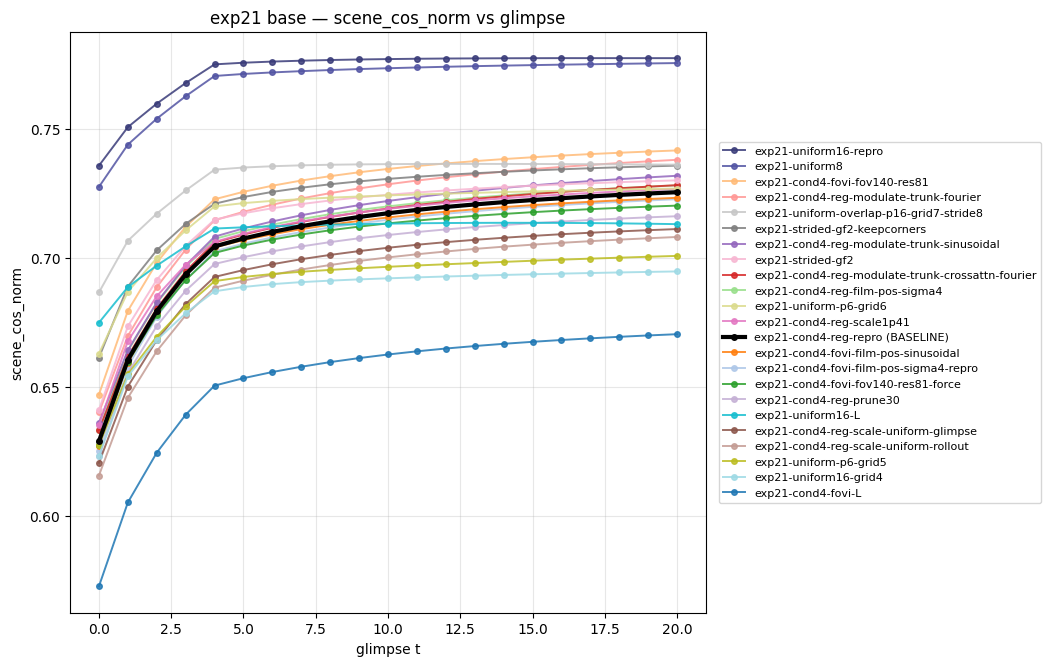

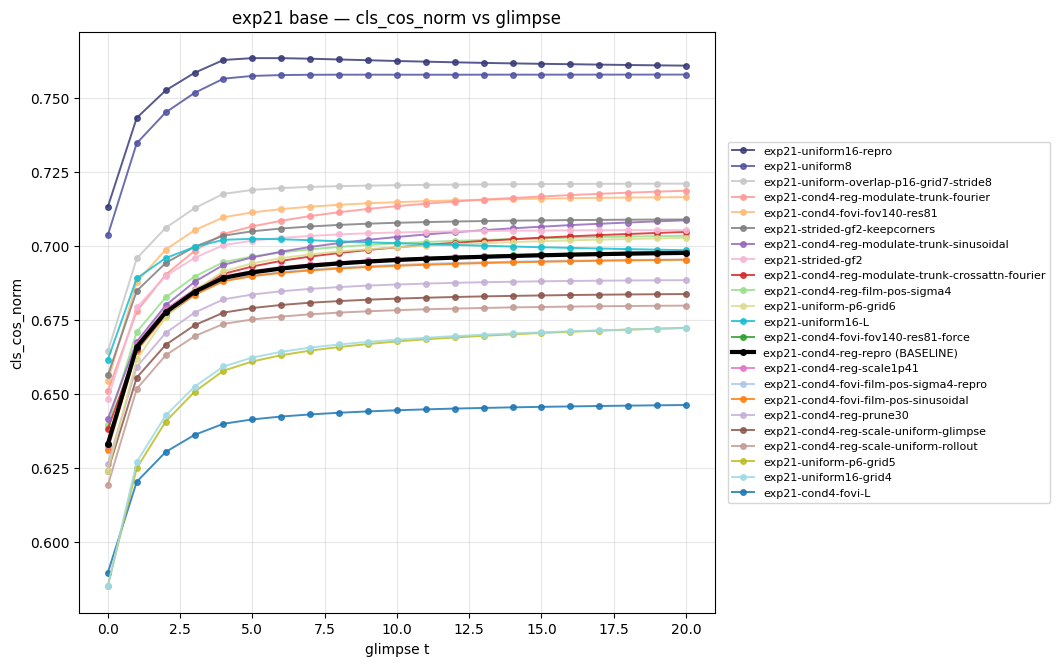

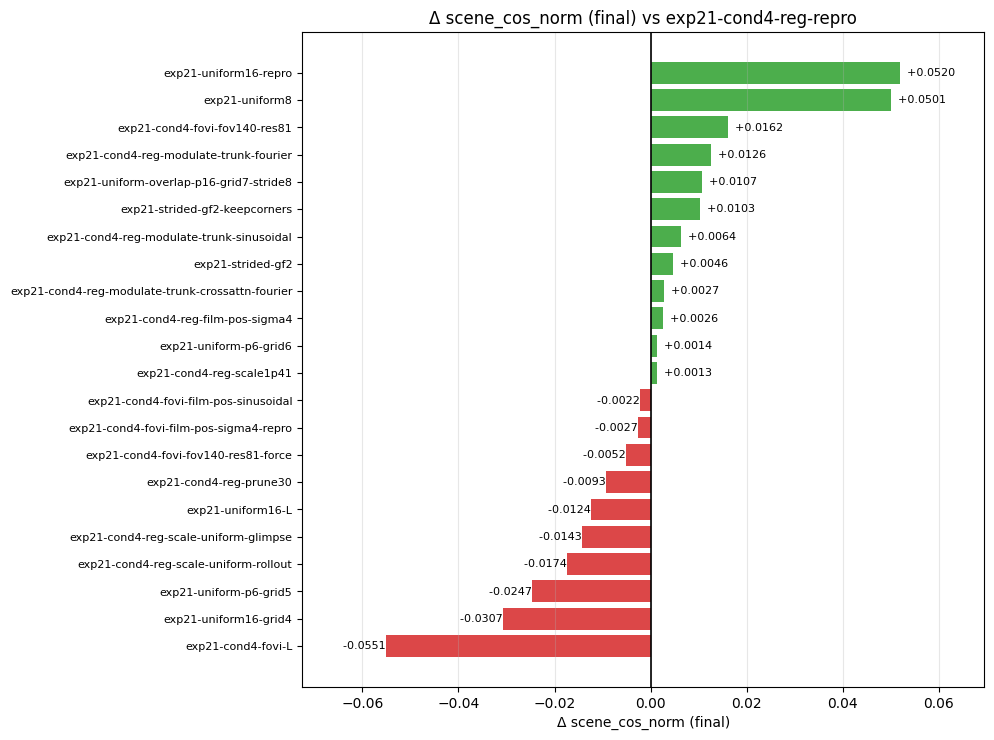

In [9]:
# scene_cos_norm and cls_cos_norm as two SEPARATE plots, each with its own
# legend ordered by that metric's final-glimpse value (descending).
for key in ("scene_cos_norm", "cls_cos_norm"):
    ranked_lineplot({r: v[key] for r, v in base_recon_by_run.items()},
                    key, f"exp21 base — {key} vs glimpse")

delta_bars({r: v["scene_cos_norm"] for r, v in base_recon_by_run.items()}, -1,
           "Δ scene_cos_norm (final)", f"Δ scene_cos_norm (final) vs {BASELINE}")

## Scale sweep — the 3 scale models at each eval scale

One panel per eval scale `{1.0(ref), coarse-to-fine, 0.6, 0.8}`, each overlaying **per_glimpse**, **per_rollout**, and **repro (scale-1 control, black dashed)**. The story:
- `per_glimpse` should hold up where the scale **varies** (coarse-to-fine).
- `per_rollout` should hold up at **fixed** in-range scales (0.6 / 0.8).
- `repro` (trained only at scale 1) should **degrade** away from 1.0 — the control.

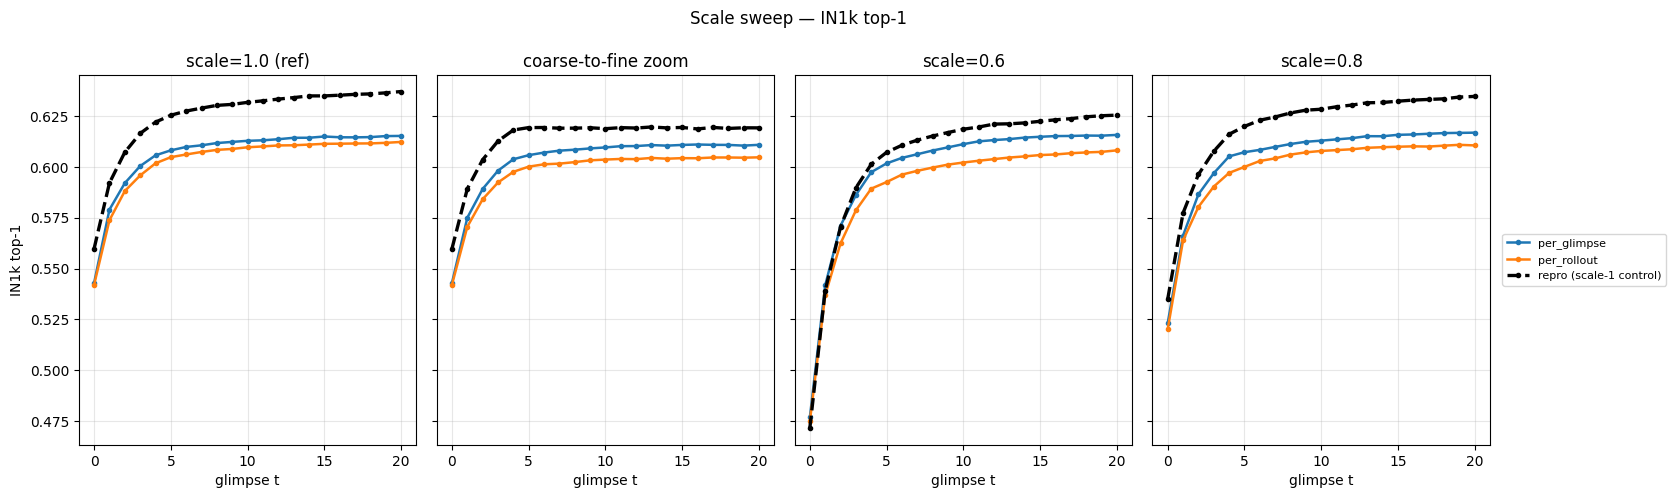

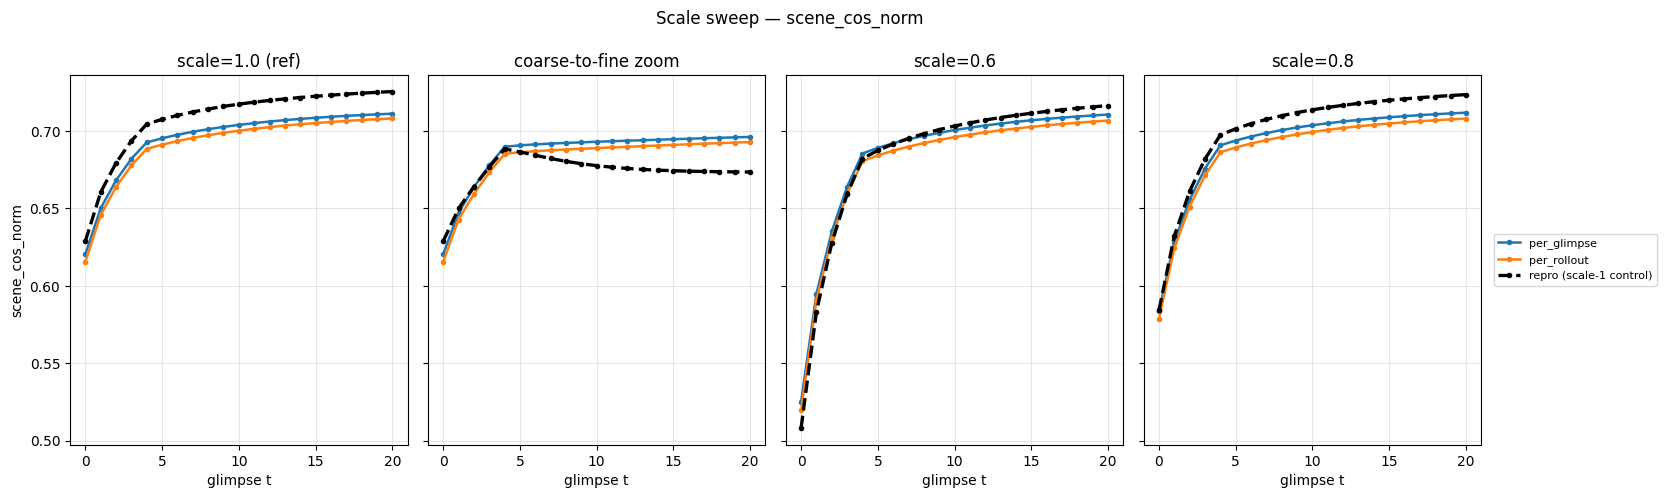

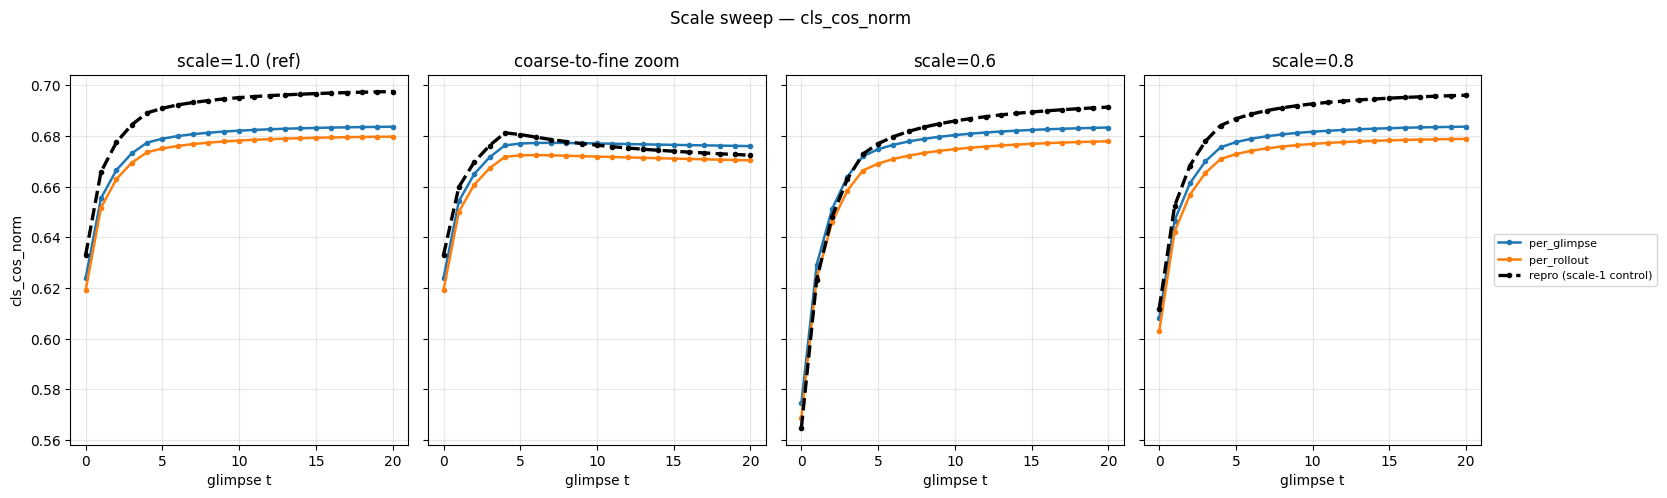

In [10]:
MODEL_COLOR = {SCALE_MODELS[0]: "tab:blue", SCALE_MODELS[1]: "tab:orange", SCALE_MODELS[2]: "black"}
MODEL_STYLE = {SCALE_MODELS[0]: "-", SCALE_MODELS[1]: "-", SCALE_MODELS[2]: "--"}

def sweep_panels(get, ylabel, title):
    fig, axes = plt.subplots(1, len(SWEEP_TAGS), figsize=(4.8 * len(SWEEP_TAGS), 5), sharey=True)
    drew = False
    for ax, tag in zip(axes, SWEEP_TAGS):
        for m in SCALE_MODELS:
            y = get(m, tag)
            if y is None:
                continue
            drew = True
            ax.plot(range(len(y)), y, marker="o", ms=3, color=MODEL_COLOR[m], ls=MODEL_STYLE[m],
                    lw=2.4 if m == BASELINE else 1.8, label=MODEL_LABEL[m])
        ax.set_title(TAG_LABEL.get(tag, tag)); ax.set_xlabel("glimpse t"); ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(ylabel)
    h, l = axes[0].get_legend_handles_labels()
    if h:
        axes[-1].legend(h, l, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    fig.suptitle(title); fig.subplots_adjust(right=0.86, wspace=0.06, top=0.85)
    plt.show() if drew else (plt.close(fig), print(f"no results yet for: {title}"))

sweep_panels(lambda m, t: in1k.get((m, t)),
             "IN1k top-1", "Scale sweep — IN1k top-1")
sweep_panels(lambda m, t: (recon.get((m, t)) or {}).get("scene_cos_norm"),
             "scene_cos_norm", "Scale sweep — scene_cos_norm")
sweep_panels(lambda m, t: (recon.get((m, t)) or {}).get("cls_cos_norm"),
             "cls_cos_norm", "Scale sweep — cls_cos_norm")

### Scale sweep — final-glimpse summary table

Final-glimpse metrics for each (model, eval scale).

In [11]:
rows = []
for m in SCALE_MODELS:
    for t in SWEEP_TAGS:
        a = in1k.get((m, t)); rr = recon.get((m, t))
        if a is None and rr is None:
            continue
        rows.append({"model": MODEL_LABEL[m], "scale": TAG_LABEL.get(t, t),
                     "in1k_top1": a[-1] if a else float("nan"),
                     "scene_cos": rr["scene_cos_norm"][-1] if rr else float("nan"),
                     "cls_cos":   rr["cls_cos_norm"][-1] if rr else float("nan")})
dfs = pd.DataFrame(rows)
display(dfs.style.format({"in1k_top1": "{:.4f}", "scene_cos": "{:.4f}", "cls_cos": "{:.4f}"})) if not dfs.empty else print("no scale-sweep results yet")

,model,scale,in1k_top1,scene_cos,cls_cos
0,per_glimpse,scale=1.0 (ref),0.6152,0.7112,0.6837
1,per_glimpse,coarse-to-fine zoom,0.6108,0.6962,0.6760
2,per_glimpse,scale=0.6,0.6157,0.7107,0.6834
3,per_glimpse,scale=0.8,0.6168,0.7119,0.6837
4,per_rollout,scale=1.0 (ref),0.6122,0.7081,0.6798
5,per_rollout,coarse-to-fine zoom,0.6047,0.6929,0.6704
6,per_rollout,scale=0.6,0.6081,0.7067,0.6779
7,per_rollout,scale=0.8,0.6105,0.7081,0.6789
8,repro (scale-1 control),scale=1.0 (ref),0.6370,0.7255,0.6976
9,repro (scale-1 control),coarse-to-fine zoom,0.6191,0.6735,0.6725
